In [1]:
# Import libraries

import numpy as np
import pandas as pd
import seaborn as sns
from pandas import Timedelta
from functools import reduce
import warnings
import matplotlib.pyplot as plt
#import statsmodels.api as sm
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy import signal
%matplotlib inline

# If you want a style choose one
#plt.style.use('Solarize_Light2')
#plt.style.use('tableau-colorblind10')
NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'

In [2]:
# Loading the raw final data into Pandas DataFrame

df = pd.read_csv(r'..\..\data_cleaned\merged\02_4_clean_data.csv', index_col=0, parse_dates=True)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 61367 entries, 2019-01-01 to 2025-12-31
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              61367 non-null  int64  
 1   month             61367 non-null  int64  
 2   day               61367 non-null  int64  
 3   dayofyear         61367 non-null  int64  
 4   hour              61367 non-null  int64  
 5   dayofweek         61367 non-null  int64  
 6   price             61367 non-null  float64
 7   period_start_utc  61367 non-null  object 
 8   period_end_utc    61367 non-null  object 
 9   load_forecast_da  61367 non-null  float64
 10  off_wind_da       61367 non-null  float64
 11  on_wind_da        61367 non-null  float64
 12  solar_da          61367 non-null  float64
 13  gen_forecast_da   61367 non-null  float64
 14  res_sum_da        61367 non-null  float64
 15  dayofyear_sin1    61367 non-null  float64
 16  dayofyear_cos1    61367

In [4]:
# Check for missing values

df.isna().sum()

year                0
month               0
day                 0
dayofyear           0
hour                0
dayofweek           0
price               0
period_start_utc    0
period_end_utc      0
load_forecast_da    0
off_wind_da         0
on_wind_da          0
solar_da            0
gen_forecast_da     0
res_sum_da          0
dayofyear_sin1      0
dayofyear_cos1      0
hour_sin1           0
hour_cos1           0
dayofweek_sin1      0
dayofweek_cos1      0
is_holiday          0
day_type            0
price_gas           0
dtype: int64

In [3]:
# Converting date columns to datetime and filtering for 2019-2025 period

df['period_start_utc'] = pd.to_datetime(df['period_start_utc'], utc=True)

start_date_df = pd.Timestamp('2019-01-01', tz='UTC')
end_date_df = pd.Timestamp('2025-12-31', tz='UTC')
df = df.query("period_start_utc >= @start_date_df")
df = df.query("period_start_utc <= @end_date_df")

print (df.columns)

Index(['year', 'month', 'day', 'dayofyear', 'hour', 'dayofweek', 'price',
       'period_start_utc', 'period_end_utc', 'load_forecast_da', 'off_wind_da',
       'on_wind_da', 'solar_da', 'gen_forecast_da', 'res_sum_da',
       'dayofyear_sin1', 'dayofyear_cos1', 'hour_sin1', 'hour_cos1',
       'dayofweek_sin1', 'dayofweek_cos1', 'is_holiday', 'day_type',
       'price_gas'],
      dtype='object')


In [4]:
# Ensure timestamp index

df.set_index('period_start_utc', inplace=True)

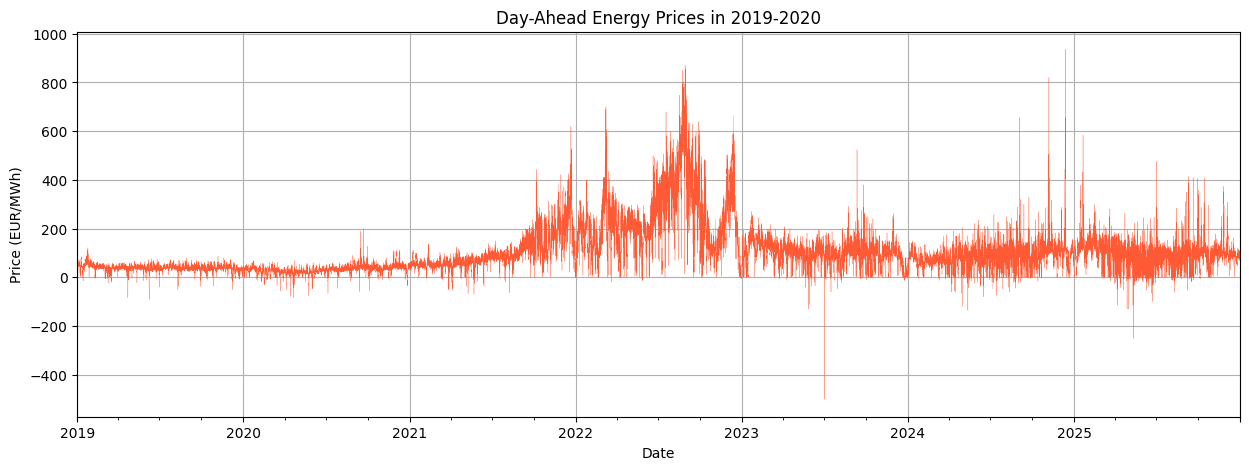

In [5]:
# Visualize the price data of the whole dataset

df['price'].plot(figsize=(15, 5), color=NF_ORANGE, linewidth=0.2)
plt.style.use('tableau-colorblind10')
plt.title('Day-Ahead Energy Prices in 2019-2020')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.grid()
plt.show()

## SARIMAX ##

The parameters are split into Non-Seasonal (short-term) and Seasonal (long-term cycle) components (p, d, q) and (P, D, Q, s).
<p>1. Non-Seasonal Order: (p, d, q)
<p>Example setting: (2, 0, 2)</p>
<p>p = 2 (Autoregressive - AR):</p> 
<p>The model looks back 2 time steps (e.g., 2 hours). It assumes the current value is a linear combination of the last two values.</p>
<p>d = 0 (Integrated - I): This is the "differencing" term used to make data stationary. Setting this to 0 means your data is already stable (doesn't have a constant upward/downward trend) and doesn't need to be subtracted from itself.</p>
<p>q = 2 (Moving Average - MA): The model looks at the error (the gap between prediction and reality) of the last 2 time steps. It uses these past mistakes to smooth out current predictions.</p>
<p>2. Seasonal Order: (P, D, Q, s)</p>
<p>Example setting: (1, 0, 1, 24)</p>
<p>This handles the repeating patterns (like how electricity prices usually peak at the same time every day).</p>
<p>P = 1 (Seasonal AR): The model looks back at the value from exactly one season ago. If $s=24$, it looks at the value from 24 hours ago.</p>
<p>D = 0 (Seasonal I): Similar to the non-seasonal $d$, this means you aren't differencing the data across seasons.</p>
<p>Q = 1 (Seasonal MA): The model looks at the prediction error from one season ago (24 hours ago) to adjust the current forecast.</p>
<p>s = 24 (Seasonal Period): This defines the length of one full cycle. Since you are likely working with hourly data, 24 tells the model that the pattern repeats every day.</p>

In [6]:
# Get dummies to one hot encode the year

df = pd.get_dummies(df, columns=['year'], drop_first=True, dtype=int)
df.columns

Index(['month', 'day', 'dayofyear', 'hour', 'dayofweek', 'price',
       'period_end_utc', 'load_forecast_da', 'off_wind_da', 'on_wind_da',
       'solar_da', 'gen_forecast_da', 'res_sum_da', 'dayofyear_sin1',
       'dayofyear_cos1', 'hour_sin1', 'hour_cos1', 'dayofweek_sin1',
       'dayofweek_cos1', 'is_holiday', 'day_type', 'price_gas', 'year_2020',
       'year_2021', 'year_2022', 'year_2023', 'year_2024', 'year_2025'],
      dtype='object')

In [7]:
# Target

y = df["price"]

# Exogenous variables

exog = df[["load_forecast_da", 'res_sum_da', 'gen_forecast_da',
       'dayofyear_sin1', 'dayofyear_cos1','hour_sin1', 'hour_cos1',
       'dayofweek_sin1', 'dayofweek_cos1', 'is_holiday', 'price_gas',
       'year_2020', 'year_2021', 'year_2022', 'year_2023', 'year_2024','year_2025'
       ]]

In [20]:
# Check for missing values in exogenous variables
exog.isna().sum()

load_forecast_da    0
res_sum_da          0
gen_forecast_da     0
dayofyear_sin1      0
dayofyear_cos1      0
hour_sin1           0
hour_cos1           0
dayofweek_sin1      0
dayofweek_cos1      0
is_holiday          0
price_gas           0
year_2020           0
year_2021           0
year_2022           0
year_2023           0
year_2024           0
year_2025           0
dtype: int64

In [8]:
# Define the exact point where training ends and testing begins
split_point = "2025-01-31 23:00:00" # Training begins from 00:00 1 February 2025

y_train = y[:split_point]
exog_train = exog[:split_point]

# For test date using a slice that starts immediately after
y_test = y[split_point:].iloc[1:] 
exog_test = exog[split_point:].iloc[1:]

In [22]:
# Check the shapes of the training and testing sets
print(f"y_train shape: {y_train.shape}")
print(f"exog_train shape: {exog_train.shape}")
print(f"y_test shape: {y_test.shape}")

exog_test.info()

y_train shape: (53352,)
exog_train shape: (53352, 17)
y_test shape: (7993,)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7993 entries, 2025-02-01 00:00:00+00:00 to 2025-12-31 00:00:00+00:00
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   load_forecast_da  7993 non-null   float64
 1   res_sum_da        7993 non-null   float64
 2   gen_forecast_da   7993 non-null   float64
 3   dayofyear_sin1    7993 non-null   float64
 4   dayofyear_cos1    7993 non-null   float64
 5   hour_sin1         7993 non-null   float64
 6   hour_cos1         7993 non-null   float64
 7   dayofweek_sin1    7993 non-null   float64
 8   dayofweek_cos1    7993 non-null   float64
 9   is_holiday        7993 non-null   int64  
 10  price_gas         7993 non-null   float64
 11  year_2020         7993 non-null   int32  
 12  year_2021         7993 non-null   int32  
 13  year_2022         7993 non-null   int32  
 14  year_2023   

In [9]:
# Convert all exogenous columns to float to ensure NumPy compatibility
exog_train = exog_train.astype(float)

# Set the frequency explicitly
#y_train = y_train.asfreq('15T')
#exog_train = exog_train.asfreq('15T')

# Now run the SARIMAX model

model = SARIMAX(
    y_train,
    exog=exog_train,
    order=(1,0,1),
    seasonal_order=(1,0,1,24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit()
print(results.summary())


e:\nf_repo\ai-for-energy\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
e:\nf_repo\ai-for-energy\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency H will be used.
  self._init_dates(dates, freq)
e:\nf_repo\ai-for-energy\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                              price   No. Observations:                53352
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood             -211378.680
Date:                            Tue, 24 Feb 2026   AIC                         422801.360
Time:                                    23:01:21   BIC                         422996.812
Sample:                                01-01-2019   HQIC                        422862.401
                                     - 01-31-2025                                         
Covariance Type:                              opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
load_forecast_da     0.0012   6.75e-05     17.720      0.000       0.001       0.001
res_sum_da       

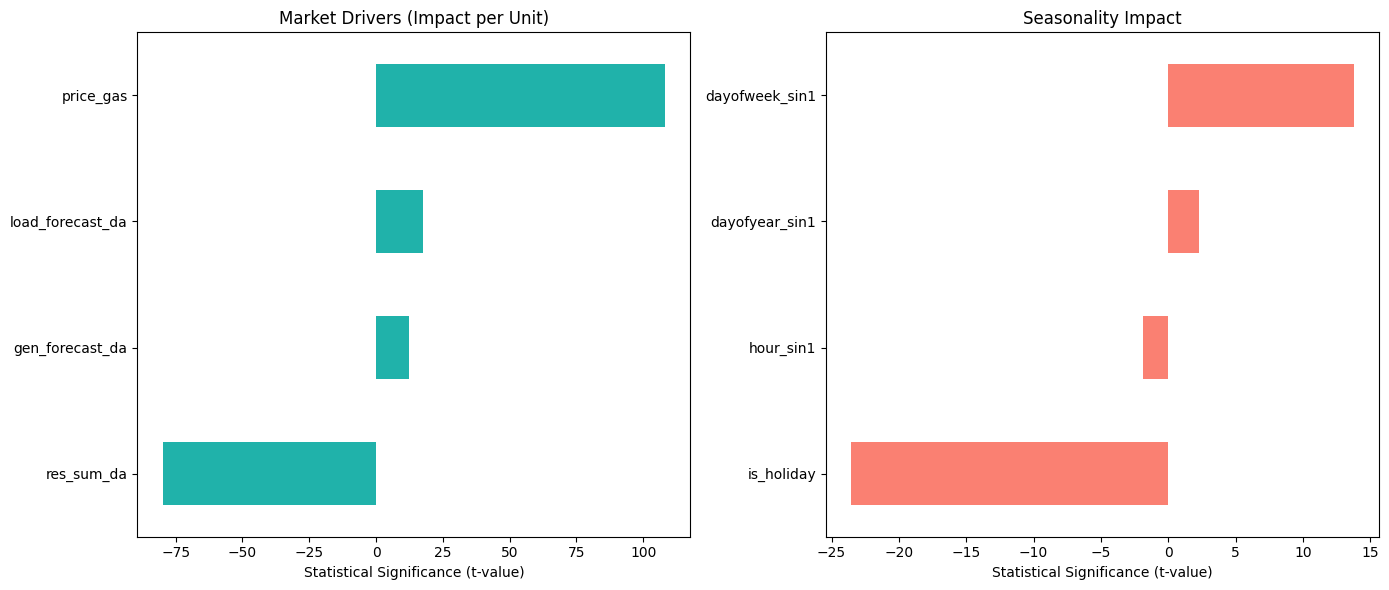

In [28]:
# Plotting impact of the various features on the price. 
# We will create a two-panel horizontal bar chart to show the coefficients of the market drivers
# and the monthly seasonality effects.

# 1. Define your feature groups based on your Model results
drivers = ['load_forecast_da', 'res_sum_da', 'gen_forecast_da', 'price_gas']
months = ['dayofyear_sin1', 'hour_sin1', 
          'dayofweek_sin1', 'is_holiday'
          ]

# 2. Extract coefficients
driver_params = results.tvalues[drivers].sort_values()
month_params = results.tvalues[months].sort_values()

# 3. Create a two-panel horizontal bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot: Market Drivers (Small scale)
driver_params.plot(kind='barh', ax=ax1, color='lightseagreen')
ax1.set_title('Market Drivers (Impact per Unit)')
ax1.set_xlabel('Statistical Significance (t-value)')

# Right Plot: Seasonal Effects (Large scale)
month_params.plot(kind='barh', ax=ax2, color='salmon')
ax2.set_title('Seasonality Impact')
ax2.set_xlabel('Statistical Significance (t-value)')

plt.tight_layout()
plt.show()

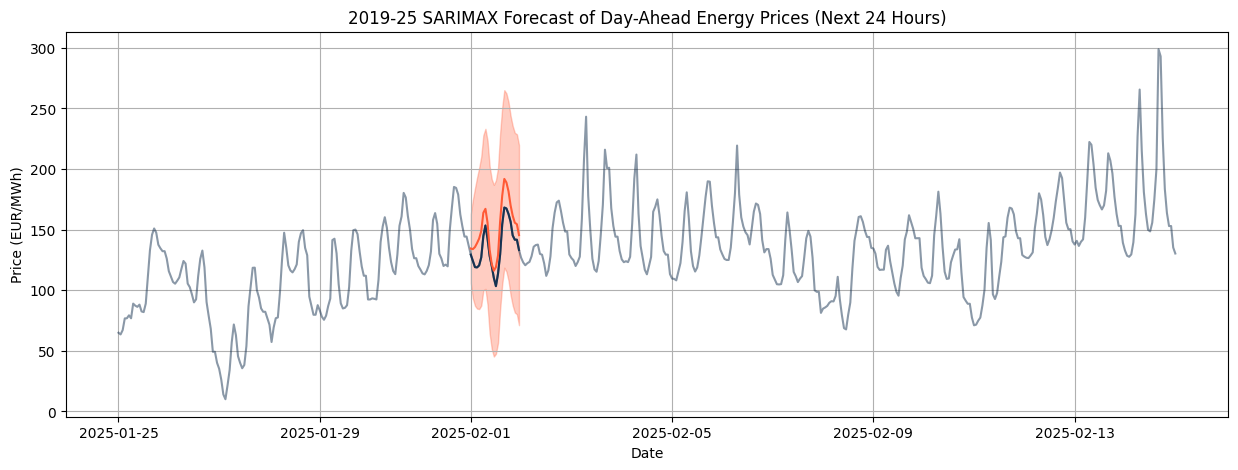

In [30]:
# Forecast next-day hourly prices

n_steps = 24

forecast = results.get_forecast(
    steps=n_steps,
    exog=exog_test.iloc[:n_steps].astype(float)
)

y_pred = forecast.predicted_mean
conf_int = forecast.conf_int()

# Plotting actual curne and the results

actual_values = y_test.loc[y_pred.index]

start_plot_date = y_test.index[0] - pd.Timedelta(days=7)  # Show 7 days of history
end_plot_date = y_test.index[0] + pd.Timedelta(days=14)  # Show 1 day of forecast
y_slice = y[start_plot_date:end_plot_date]  # Historical data up to the start of the test set

plt.figure(figsize=(15, 5))
plt.plot(y_slice.index, y_slice, label='Historical', color=NF_BLUE, alpha=0.5)
#plt.plot(y_test.index[:n_steps], y_test[:n_steps], label='Actual', color=NF_BLUE)
plt.plot(actual_values.index, actual_values, label='Actual', color=NF_BLUE)
plt.plot(y_pred.index, y_pred, label='Predicted', color=NF_ORANGE)
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color=NF_ORANGE, alpha=0.3, label='Confidence Interval')
plt.title('2019-25 SARIMAX Forecast of Day-Ahead Energy Prices (Next 24 Hours)')
plt.grid()
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.show()

#### Model comparison ##

|Metric        | SARIMAX    | ARIMA     | Interpretation |
|--------------|------------|-----------|----------------|
|Log-Likelihood|"−30,910.8" |           |Higher is better. SARIMAX fits the data much more closely.|
|AIC           |"61,839.6"  |           |"Lower is better. A difference of >10 is significant; ~25,000 is massive."|
|BIC           |"61,902.5"  |           |Lower is better. SARIMAX is preferred even after penalizing for more parameters.|
|σ2 (Error Variance)|"158.35"|          |Lower is better. SARIMAX has  94% less unexplained variance.|

In [31]:
# Assessing the models with RMSE and MAE

rms_sarimax = np.sqrt(mean_squared_error(y_test[:n_steps], y_pred))
mae_sarimax = np.mean(np.abs(y_test[:n_steps] - y_pred))

# Printing RMSE of all the methods
print("RMSE ", round(rms_sarimax,3))
print("MAE: ", round(mae_sarimax,3))

RMSE  16.648
MAE:  15.337


In [ ]:
# 1. Create a DataFrame from your arrays
export_df = pd.DataFrame({
    'time_stamp': y_pred.index[0:24],
    'pred_price': y_pred[0:24]
})

# 2. Export to CSV
# index=False prevents pandas from adding an extra 'unnamed' column for the row numbers
export_df.to_csv('sarimax_2019_2025_predictions.csv', index=False)